In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (8, 6)

In [ ]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print('Nama kelas :', wine.target_names)
df['target'].value_counts()

Nama kelas : ['class_0' 'class_1' 'class_2']


,count
target,
1,71
0,59
2,48


In [ ]:
x = wine.data
y = wine.target

print('shape x:', x.shape)
print('shape y:', y.shape)

shape x: (178, 13)
shape y: (178,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('shape x:', x_test.shape)
print('shape y:', y_test.shape)

shape x: (36, 13)
shape y: (36,)


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled[:5]

array([[ 0.38580089, -0.63787118,  1.77666817, -1.22453161,  0.69643032,
         0.52686525,  0.73229212, -0.1695489 , -0.41578344, -0.16746725,
         0.62437819,  0.2529082 ,  0.46772474],
       [ 0.94851892, -0.76544542,  1.25317383,  0.85328406,  0.09178497,
         1.17279546,  1.33318146, -0.59045701,  1.34974202,  0.30530313,
         1.06715537,  0.15104809,  1.81576773],
       [ 0.52335419, -0.51940939,  0.9540342 , -1.04643312, -0.44567755,
         0.93057163,  1.006382  , -0.1695489 , -0.26000178, -0.081509  ,
        -0.12834302,  0.89317174,  1.51620262],
       [ 0.97352861, -0.55585917,  0.16879269, -1.0761162 , -0.71440882,
         0.52686525,  0.81662747, -0.59045701,  0.36312485,  0.262324  ,
         0.8900445 ,  0.42752553,  1.93226527],
       [ 0.43582027,  0.82012009,  0.05661533,  0.55645325, -0.51286037,
        -0.55506784, -1.29175618,  0.75644894, -0.60618325,  1.47433535,
        -1.76661859, -1.43505932, -0.29783054]])

In [ ]:
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(x_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(x_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

print('Akurasi tanpa PCA:', acc_no_pca)
print('\nClassification report(tanpa pca)')
print(classification_report(y_test, y_pred_no_pca, target_names=wine.target_names))

Akurasi tanpa PCA: 0.9722222222222222

Classification report(tanpa pca)
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [ ]:
pca = PCA(n_components=3)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print('shape x:', x_train_pca.shape)
print('shape x:', x_test_pca.shape)

shape x: (142, 3)
shape x: (36, 3)


In [ ]:
explained_var = pca.explained_variance_ratio_
print('variance ratio tiap komponen:', explained_var)
print('total variance ratio yang dijelaskan 3 komponen pertama:', sum(explained_var))

variance ratio tiap komponen: [0.35792104 0.19270671 0.11019835]
total variance ratio yang dijelaskan 3 komponen pertama: 0.6608261082211259


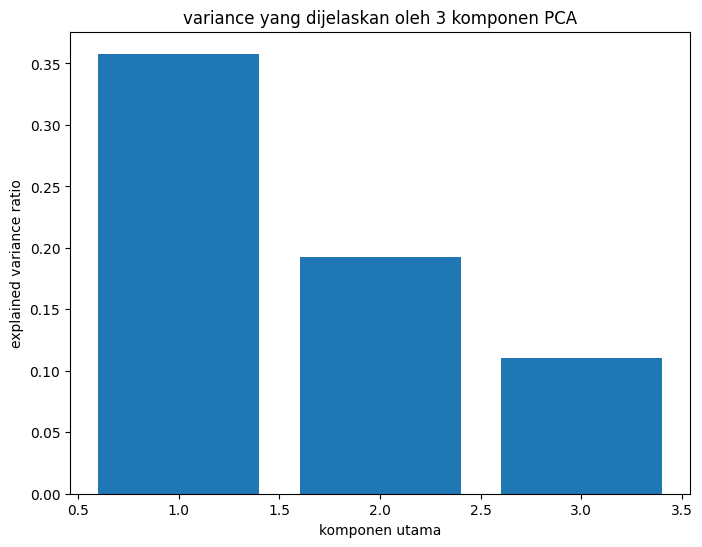

In [ ]:
plt.bar([1,2,3], explained_var)
plt.xlabel('komponen utama')
plt.ylabel('explained variance ratio')
plt.title('variance yang dijelaskan oleh 3 komponen PCA')
plt.show()

In [ ]:
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(x_train_pca, y_train)

y_pred_pca = svm_pca.predict(x_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print('Akurasi dengan PCA:', acc_pca)

print('\nClassification report(dengan pca)')
print(classification_report(y_test, y_pred_pca, target_names=wine.target_names))

Akurasi dengan PCA: 0.9722222222222222

Classification report(dengan pca)
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



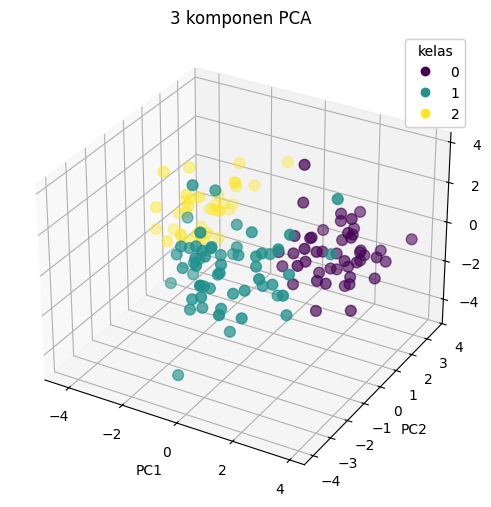

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x_train_pca[:, 0], x_train_pca[:, 1], x_train_pca[:, 2], c=y_train, s=60)
ax.set_title('3 komponen PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
legend1 = ax.legend(*scatter.legend_elements(), title='kelas')
ax.add_artist(legend1)
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA'],
    'Jummlah fitur' : [x_train_scaled.shape[1], x_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi total PCA' : [None, explained_var.sum()]
})

comparison

,Model,Jummlah fitur,Akurasi,Variansi total PCA
0,SVM tanpa PCA,13,0.972222,NaN
1,SVM dengan PCA,3,0.972222,0.660826


<function matplotlib.pyplot.show(close=None, block=None)>

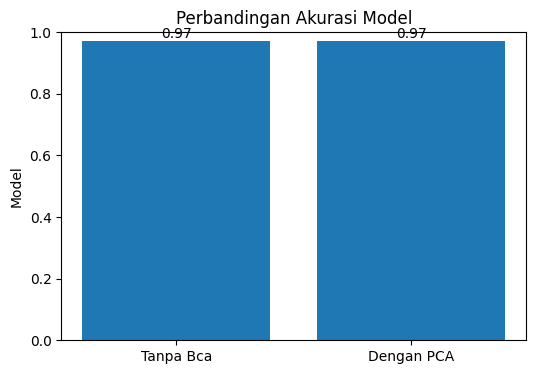

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(['Tanpa Bca', 'Dengan PCA'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Model')
plt.ylim(0, 1)
for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show